# Module 22: Week 11 BBO Optimization

## HEBO-Inspired Upgrades + Tight Exploitation

Week 10 delivered **4/8 new bests** (F1, F5, F7, F8), with F1's +12.4% being the project's biggest single-week improvement.

With **2 exploration weeks remaining** (11, 12) before Week 13's EXACT_RETURN, we add 3 improvements from **HEBO** (NeurIPS 2020 BBO Challenge winner, Huawei Noah's Ark Lab):

1. **Output Warping (Yeo-Johnson)** — transforms skewed y-distributions for better GP fitting
2. **Noisy EI for F2** — uses GP-predicted incumbent instead of noisy observed best
3. **Multi-Acquisition Ensemble** — combines PI+EI+UCB scores (HEBO-style Pareto selection)

### Week 10 Results Summary
| Function | Week 10 Value | Previous Best | Result |
|----------|--------------|---------------|--------|
| F1 | **1.993** | 1.773 | **NEW BEST** (+12.4%, coordinate-wise search!) |
| F2 | 0.590 | 0.667 | Regression (EXACT_RETURN, confirms noise) |
| F3 | -0.027 | -0.0117 | Regression (trajectory overshot) |
| F4 | 0.536 | 0.629 | Regression (r=0.010 still too large) |
| F5 | **1675.3** | 1674.2 | **NEW BEST** (+1.1, near-optimal) |
| F6 | -0.628 | -0.586 | Regression (half-step trajectory failed) |
| F7 | **2.480** | 2.448 | **NEW BEST** (+0.032, directional exploit) |
| F8 | **9.937** | 9.933 | **NEW BEST** (+0.004, ultra-tight exploit) |

In [1]:
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.model_selection import LeaveOneOut
from scipy.optimize import minimize, differential_evolution
from scipy.stats import norm, qmc
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.join(os.path.dirname(os.path.abspath('.')), 'src'))
sys.path.append('../src')
from utils import load_data, save_submission

np.random.seed(42)
print("Week 11 (Module 22) — HEBO-Inspired Optimization")
print("Upgrades: Output Warping (Yeo-Johnson) + Noisy EI + Multi-Acquisition Ensemble")

Week 11 (Module 22) — HEBO-Inspired Optimization
Upgrades: Output Warping (Yeo-Johnson) + Noisy EI + Multi-Acquisition Ensemble


## 1. Load All Data and Verify Week 10 Additions

In [2]:
def fmt(arr, d=6):
    return [round(float(x), d) for x in arr]

# Load all data
best_values = {}
best_locations = {}
all_data = {}
dims = {}

for func_id in range(1, 9):
    df = load_data(func_id)
    all_data[func_id] = df
    dim = len([c for c in df.columns if c.startswith('x')])
    dims[func_id] = dim
    
    best_idx = df['y'].idxmax()
    best_y = df.loc[best_idx, 'y']
    best_x = df.loc[best_idx, [f'x{i}' for i in range(dim)]].values
    
    best_values[func_id] = best_y
    best_locations[func_id] = best_x
    
    print(f"F{func_id} ({dim}D): Best = {best_y:.6f} at {fmt(best_x, 4)}")
    print(f"   Points: {len(df)}, Source: {df.loc[best_idx, 'source']}")

# Verify Week 9 data was added
print("\n" + "=" * 60)
print("Verification: Week 9 rows")
print("=" * 60)
for func_id in range(1, 9):
    df = all_data[func_id]
    w9 = df[df['source'] == 'week_9_submission']
    if len(w9) > 0:
        print(f"F{func_id}: y = {w9['y'].values[0]:.6f} ✓")
    else:
        print(f"F{func_id}: MISSING Week 9 data!")

F1 (2D): Best = 1.993006 at [0.6297, 0.6287]
   Points: 20, Source: week_10_submission
F2 (2D): Best = 0.666983 at [0.7026, 0.9266]
   Points: 20, Source: week_4_submission
F3 (3D): Best = -0.011662 at [0.5296, 0.639, 0.3896]
   Points: 25, Source: week_9_submission
F4 (4D): Best = 0.628683 at [0.4234, 0.3779, 0.4125, 0.4247]
   Points: 40, Source: week_8_submission
F5 (4D): Best = 1675.335081 at [0.3688, 0.2765, 1.0, 1.0]
   Points: 30, Source: week_10_submission
F6 (5D): Best = -0.586391 at [0.6902, 0.1258, 0.7578, 0.7367, 0.051]
   Points: 30, Source: week_8_submission
F7 (6D): Best = 2.479887 at [0.0136, 0.1335, 0.5825, 0.2327, 0.3714, 0.7454]
   Points: 40, Source: week_10_submission
F8 (8D): Best = 9.937023 at [0.0339, 0.0872, 0.148, 0.0589, 0.8784, 0.3502, 0.1668, 0.2351]
   Points: 50, Source: week_10_submission

Verification: Week 9 rows
F1: y = 1.583358 ✓
F2: y = 0.509538 ✓
F3: y = -0.011662 ✓
F4: y = 0.398147 ✓
F5: y = 1674.227482 ✓
F6: y = -0.668418 ✓
F7: y = 2.447579 ✓
F8:

In [3]:
# Compute improvement trajectories for functions with recent improvement
def compute_improvement_direction(df, dim):
    """Compute direction of improvement from top submissions."""
    x_cols = [f'x{i}' for i in range(dim)]
    
    # Get top submissions sorted by y value
    top = df.nlargest(3, 'y')
    
    if len(top) < 2:
        return None
    
    x_best = top.iloc[0][x_cols].values.astype(float)
    x_second = top.iloc[1][x_cols].values.astype(float)
    
    direction = x_best - x_second
    norm_val = np.linalg.norm(direction)
    
    if norm_val < 1e-10:
        return None
    
    return direction / norm_val, norm_val

print("Improvement trajectories:")
print("=" * 60)
trajectories = {}
for func_id in range(1, 9):
    result = compute_improvement_direction(all_data[func_id], dims[func_id])
    if result is not None:
        direction, magnitude = result
        trajectories[func_id] = direction
        print(f"F{func_id}: direction = {fmt(direction, 4)}, step size = {magnitude:.4f}")
    else:
        print(f"F{func_id}: No clear improvement direction")

Improvement trajectories:
F1: direction = [-0.1433, 0.9897], step size = 0.0070
F2: direction = [0.9133, -0.4072], step size = 0.0000
F3: direction = [0.5791, 0.5648, 0.5879], step size = 0.0169
F4: direction = [0.2559, -0.5006, 0.7496, 0.3491], step size = 0.0736
F5: direction = [0.8998, 0.4331, 0.0417, 0.0315], step size = 0.0010
F6: direction = [0.7999, 0.0106, 0.0543, -0.5835, 0.1287], step size = 0.0216
F7: direction = [-0.0321, 0.128, 0.132, 0.973, 0.0085, -0.1356], step size = 0.0160
F8: direction = [0.1144, 0.0212, -0.0746, 0.0343, -0.2184, 0.6595, 0.0488, 0.7034], step size = 0.0111


## 2. Multi-Kernel GP Ensemble (HEBO Upgrade A: Output Warping)

**NEW**: Replaced `StandardScaler` on y with `PowerTransformer(method='yeo-johnson')`.
This is the #1 technique from HEBO (NeurIPS 2020 BBO winner). It transforms skewed y-distributions
to be more Gaussian, improving GP fit quality — especially for F1 (y spans 1e-79 to 1.99) and F5 (y~1600).

In [4]:
class RobustMultiKernelGP:
    """Multi-kernel GP ensemble with Yeo-Johnson output warping (HEBO-inspired)."""
    
    def __init__(self, dim):
        self.dim = dim
        self.gps = []
        self.weights = []
        self.scaler_X = StandardScaler()
        # HEBO Upgrade A: PowerTransformer instead of StandardScaler for y
        self.scaler_y = PowerTransformer(method='yeo-johnson', standardize=True)
        self.loo_scores = []
        
    def fit(self, X, y):
        X_scaled = self.scaler_X.fit_transform(X)
        y_warped = self.scaler_y.fit_transform(y.reshape(-1, 1)).ravel()
        
        nus = [0.5, 1.5, 2.5]
        self.gps = []
        log_marginal_likelihoods = []
        self.loo_scores = []
        
        for nu in nus:
            kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
                length_scale=np.ones(self.dim),
                length_scale_bounds=(1e-2, 1e2),
                nu=nu
            ) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-10, 1e1))
            
            gp = GaussianProcessRegressor(
                kernel=kernel,
                n_restarts_optimizer=10,
                normalize_y=False,
                alpha=1e-6
            )
            gp.fit(X_scaled, y_warped)
            self.gps.append(gp)
            log_marginal_likelihoods.append(gp.log_marginal_likelihood_value_)
            
            # Fast LOO-CV: reuse fitted kernel (n_restarts_optimizer=0)
            loo = LeaveOneOut()
            loo_errors = []
            for train_idx, test_idx in loo.split(X_scaled):
                gp_loo = GaussianProcessRegressor(
                    kernel=gp.kernel_, n_restarts_optimizer=0,
                    normalize_y=False, alpha=1e-6
                )
                gp_loo.fit(X_scaled[train_idx], y_warped[train_idx])
                pred = gp_loo.predict(X_scaled[test_idx])
                loo_errors.append((pred[0] - y_warped[test_idx[0]])**2)
            self.loo_scores.append(np.mean(loo_errors))
        
        # Combine LML and LOO-CV for weights
        lml = np.array(log_marginal_likelihoods)
        lml = lml - np.max(lml)
        lml_weights = np.exp(lml)
        lml_weights = lml_weights / np.sum(lml_weights)
        
        # LOO weights (inverse error, lower = better)
        loo_arr = np.array(self.loo_scores)
        loo_inv = 1.0 / (loo_arr + 1e-10)
        loo_weights = loo_inv / np.sum(loo_inv)
        
        # Average both weight sources
        self.weights = 0.6 * lml_weights + 0.4 * loo_weights
        self.weights = self.weights / np.sum(self.weights)
        
        print(f"  Output warping: Yeo-Johnson (lambda={self.scaler_y.lambdas_[0]:.3f})")
        print(f"  LML weights:  v=0.5: {lml_weights[0]:.3f}, v=1.5: {lml_weights[1]:.3f}, v=2.5: {lml_weights[2]:.3f}")
        print(f"  LOO weights:  v=0.5: {loo_weights[0]:.3f}, v=1.5: {loo_weights[1]:.3f}, v=2.5: {loo_weights[2]:.3f}")
        print(f"  Final weights: v=0.5: {self.weights[0]:.3f}, v=1.5: {self.weights[1]:.3f}, v=2.5: {self.weights[2]:.3f}")
        print(f"  LOO-CV RMSE:  v=0.5: {np.sqrt(self.loo_scores[0]):.4f}, v=1.5: {np.sqrt(self.loo_scores[1]):.4f}, v=2.5: {np.sqrt(self.loo_scores[2]):.4f}")
    
    def predict(self, X, return_std=True):
        X_scaled = self.scaler_X.transform(X)
        
        mu_ensemble = np.zeros(len(X))
        var_ensemble = np.zeros(len(X))
        
        for gp, w in zip(self.gps, self.weights):
            mu_i, sigma_i = gp.predict(X_scaled, return_std=True)
            mu_ensemble += w * mu_i
            var_ensemble += w * (sigma_i**2 + mu_i**2)
        
        var_ensemble -= mu_ensemble**2
        sigma_ensemble = np.sqrt(np.maximum(var_ensemble, 1e-10))
        
        # Inverse-transform from warped space back to original
        mu_orig = self.scaler_y.inverse_transform(mu_ensemble.reshape(-1, 1)).ravel()
        
        # For sigma: use the derivative of the inverse transform (chain rule)
        # Approximate: sigma_orig ≈ sigma_warped * |d(inverse)/d(warped)| at mu
        # For Yeo-Johnson with small lambda, this is approximately:
        # We compute it numerically for accuracy
        mu_plus = self.scaler_y.inverse_transform((mu_ensemble + sigma_ensemble).reshape(-1, 1)).ravel()
        mu_minus = self.scaler_y.inverse_transform((mu_ensemble - sigma_ensemble).reshape(-1, 1)).ravel()
        sigma_orig = (mu_plus - mu_minus) / 2.0
        sigma_orig = np.maximum(sigma_orig, 1e-10)
        
        if return_std:
            return mu_orig, sigma_orig
        return mu_orig
    
    def predict_warped(self, X, return_std=True):
        """Predict in warped space (useful for acquisition functions)."""
        X_scaled = self.scaler_X.transform(X)
        
        mu_ensemble = np.zeros(len(X))
        var_ensemble = np.zeros(len(X))
        
        for gp, w in zip(self.gps, self.weights):
            mu_i, sigma_i = gp.predict(X_scaled, return_std=True)
            mu_ensemble += w * mu_i
            var_ensemble += w * (sigma_i**2 + mu_i**2)
        
        var_ensemble -= mu_ensemble**2
        sigma_ensemble = np.sqrt(np.maximum(var_ensemble, 1e-10))
        
        if return_std:
            return mu_ensemble, sigma_ensemble
        return mu_ensemble
    
    def sample_posterior_diagonal(self, X, n_samples=100):
        """Fast Thompson Sampling using diagonal approximation (in original space)."""
        mu, sigma = self.predict(X, return_std=True)
        samples = mu[:, np.newaxis] + sigma[:, np.newaxis] * np.random.randn(len(X), n_samples)
        return samples

## 3. Acquisition Functions (HEBO Upgrades B & C)

**Upgrade B**: Noisy EI — uses GP-predicted incumbent instead of observed best (for F2).
**Upgrade C**: Multi-acquisition ensemble — combines PI+EI+UCB scores instead of betting on one.

In [5]:
def ucb(mu, sigma, kappa=2.0):
    """Upper Confidence Bound."""
    return mu + kappa * sigma

def expected_improvement(mu, sigma, y_best, xi=0.01):
    """Expected Improvement."""
    improvement = mu - y_best - xi
    Z = improvement / (sigma + 1e-10)
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return np.where(sigma > 1e-10, ei, 0.0)

def probability_of_improvement(mu, sigma, y_best, xi=0.001):
    """Probability of Improvement — good for exploitation."""
    Z = (mu - y_best - xi) / (sigma + 1e-10)
    return norm.cdf(Z)

def thompson_sampling_idx(gp_ensemble, X_candidates, n_samples=100):
    """Thompson Sampling via fast diagonal approximation."""
    samples = gp_ensemble.sample_posterior_diagonal(X_candidates, n_samples=n_samples)
    best_indices = np.argmax(samples, axis=0)
    from collections import Counter
    counter = Counter(best_indices.tolist())
    return counter.most_common(1)[0][0]

def multi_acquisition_ensemble(mu, sigma, y_best, kappa=1.5, 
                                pi_weight=0.5, ei_weight=0.3, ucb_weight=0.2):
    """
    HEBO Upgrade C: Multi-acquisition ensemble selection.
    Computes PI, EI, UCB simultaneously and returns combined score.
    """
    pi_scores = probability_of_improvement(mu, sigma, y_best, xi=0.001)
    ei_scores = expected_improvement(mu, sigma, y_best, xi=0.01)
    ucb_scores = ucb(mu, sigma, kappa=kappa)
    
    # Normalize each to [0, 1]
    def normalize(arr):
        rng = arr.max() - arr.min()
        if rng < 1e-10:
            return np.ones_like(arr) * 0.5
        return (arr - arr.min()) / rng
    
    pi_norm = normalize(pi_scores)
    ei_norm = normalize(ei_scores)
    ucb_norm = normalize(ucb_scores)
    
    combined = pi_weight * pi_norm + ei_weight * ei_norm + ucb_weight * ucb_norm
    return combined, pi_scores, ei_scores, ucb_scores

## 4. Trust Region Classes (updated with constraints support)

In [6]:
from scipy.stats.qmc import Sobol

class DirectionalTrustRegion:
    """Trust region with optional directional bias for exploitation."""
    
    def __init__(self, dim, center, radius=0.05, direction=None, direction_weight=0.3):
        self.dim = dim
        self.center = np.array(center, dtype=float)
        self.radius = radius
        self.direction = np.array(direction, dtype=float) if direction is not None else None
        self.direction_weight = direction_weight
    
    def generate_candidates(self, n_candidates=20000):
        """Generate candidates with optional directional bias."""
        sobol = Sobol(d=self.dim, scramble=True, seed=42)
        sobol_samples = sobol.random(n_candidates)
        base_candidates = self.center + (sobol_samples - 0.5) * 2 * self.radius
        
        if self.direction is not None:
            n_directional = int(n_candidates * self.direction_weight)
            n_uniform = n_candidates - n_directional
            
            dir_candidates = []
            for _ in range(n_directional):
                step = np.random.uniform(0, 1.5 * self.radius)
                lateral = np.random.normal(0, self.radius * 0.3, self.dim)
                lateral -= np.dot(lateral, self.direction) * self.direction
                candidate = self.center + step * self.direction + lateral
                dir_candidates.append(candidate)
            
            dir_candidates = np.array(dir_candidates)
            all_candidates = np.vstack([base_candidates[:n_uniform], dir_candidates])
        else:
            all_candidates = base_candidates
        
        all_candidates = np.clip(all_candidates, 0.0, 1.0)
        return all_candidates


class BoundaryAwareTrustRegion:
    """Trust region that pins specified dimensions near boundary values."""
    
    def __init__(self, dim, center, radius=0.05,
                 pinned_dims=None, pinned_range=(0.99, 0.999)):
        self.dim = dim
        self.center = np.array(center, dtype=float)
        self.radius = radius
        self.pinned_dims = pinned_dims or []
        self.pinned_range = pinned_range
    
    def generate_candidates(self, n_candidates=20000):
        sobol = Sobol(d=self.dim, scramble=True, seed=42)
        sobol_samples = sobol.random(n_candidates)
        
        candidates = self.center + (sobol_samples - 0.5) * 2 * self.radius
        
        # Clip to [0, 1] FIRST
        candidates = np.clip(candidates, 0.0, 1.0)
        
        # Then pin specified dimensions (AFTER clipping)
        for d in self.pinned_dims:
            candidates[:, d] = np.random.uniform(
                self.pinned_range[0], self.pinned_range[1], n_candidates
            )
        
        return candidates

## 5. Main Optimization Engine (Week 11: HEBO upgrades integrated)

Now supports:
- `selection='multi'` — multi-acquisition ensemble (Upgrade C)
- `selection='noisy_ei'` — noisy EI using GP-predicted incumbent (Upgrade B)
- Output warping via Yeo-Johnson in RobustMultiKernelGP (Upgrade A)

In [7]:
def optimize_function(func_id, strategy='exploit', custom_radius=None,
                      direction=None, pinned_dims=None, pinned_range=None,
                      kappa=2.0, n_candidates=20000,
                      selection='auto', center_override=None,
                      constraints=None, direction_weight=0.4,
                      pi_weight=0.5, ei_weight=0.3, ucb_weight=0.2):
    """
    Generate next query for a function.
    
    Week 11 additions:
    - selection='multi': HEBO-style multi-acquisition ensemble
    - selection='noisy_ei': uses GP-predicted best as incumbent (for noisy functions)
    - Output warping via Yeo-Johnson in RobustMultiKernelGP
    """
    df = all_data[func_id]
    dim = dims[func_id]
    
    X = df[[f'x{i}' for i in range(dim)]].values
    y = df['y'].values
    
    y_best = np.max(y)
    best_idx = np.argmax(y)
    x_best = X[best_idx]
    
    center = center_override if center_override is not None else x_best
    
    print(f"\n{'='*60}")
    print(f"Function {func_id} ({dim}D) — Strategy: {strategy}, Selection: {selection}")
    print(f"Best observed: {y_best:.6f} at {fmt(x_best, 4)}")
    if center_override is not None:
        print(f"Center override: {fmt(center, 4)}")
    if constraints:
        print(f"Constraints: {constraints}")
    print(f"Data points: {len(df)}")
    print(f"{'='*60}")
    
    # Build ensemble model (now with Yeo-Johnson output warping)
    ensemble = RobustMultiKernelGP(dim)
    ensemble.fit(X, y)
    
    # HEBO Upgrade B: For noisy EI, use GP-predicted best instead of observed best
    if selection == 'noisy_ei':
        mu_train = ensemble.predict(X, return_std=False)
        y_best_for_acq = np.max(mu_train)
        print(f"  Noisy EI: GP-predicted best = {y_best_for_acq:.6f} (observed best = {y_best:.6f})")
    else:
        y_best_for_acq = y_best
    
    # Determine radius
    if custom_radius:
        radius = custom_radius
    elif strategy == 'exploit':
        radius = 0.02
    elif strategy == 'directional':
        radius = 0.03
    elif strategy == 'turbo':
        radius = 0.05
    elif strategy == 'explore':
        radius = 0.15
    elif strategy == 'boundary':
        radius = 0.03
    else:
        radius = 0.05
    
    print(f"  Trust region radius: {radius}")
    
    # Generate candidates based on strategy
    if strategy == 'directional' and direction is not None:
        tr = DirectionalTrustRegion(dim, center, radius, direction, direction_weight=direction_weight)
        print(f"  Direction: {fmt(direction, 4)}")
    elif strategy == 'boundary' and pinned_dims is not None:
        pr = pinned_range or (0.99, 0.999)
        tr = BoundaryAwareTrustRegion(dim, center, radius, pinned_dims, pr)
        print(f"  Pinned dims: {pinned_dims} to range {pr}")
    else:
        tr = DirectionalTrustRegion(dim, center, radius)
    
    X_candidates = tr.generate_candidates(n_candidates)
    
    # Apply hard constraints
    if constraints:
        mask = np.ones(len(X_candidates), dtype=bool)
        for dim_idx, min_val, max_val in constraints:
            mask &= (X_candidates[:, dim_idx] >= min_val)
            mask &= (X_candidates[:, dim_idx] <= max_val)
        n_removed = np.sum(~mask)
        X_candidates = X_candidates[mask]
        print(f"  After constraints: {len(X_candidates)} candidates (removed {n_removed})")
    
    # Predict
    mu, sigma = ensemble.predict(X_candidates)
    
    # Multiple acquisition functions
    ucb_values = ucb(mu, sigma, kappa=kappa)
    ei_values = expected_improvement(mu, sigma, y_best_for_acq, xi=0.01)
    pi_values = probability_of_improvement(mu, sigma, y_best_for_acq, xi=0.001)
    
    ucb_idx = np.argmax(ucb_values)
    ei_idx = np.argmax(ei_values)
    pi_idx = np.argmax(pi_values)
    mean_idx = np.argmax(mu)
    
    # HEBO Upgrade C: Multi-acquisition ensemble
    multi_scores, _, _, _ = multi_acquisition_ensemble(
        mu, sigma, y_best_for_acq, kappa=kappa,
        pi_weight=pi_weight, ei_weight=ei_weight, ucb_weight=ucb_weight
    )
    multi_idx = np.argmax(multi_scores)
    
    candidates = [
        ('UCB', ucb_idx, ucb_values[ucb_idx]),
        ('EI', ei_idx, ei_values[ei_idx]),
        ('PI', pi_idx, pi_values[pi_idx]),
        ('Mean', mean_idx, mu[mean_idx]),
        ('Multi', multi_idx, multi_scores[multi_idx]),
    ]
    
    print(f"\n  Acquisition recommendations:")
    for name, idx, score in candidates:
        mu_i, sig_i = ensemble.predict(X_candidates[idx:idx+1])
        print(f"    {name}: {fmt(X_candidates[idx], 4)} | pred={mu_i[0]:.4f} +/- {sig_i[0]:.4f} | acq={score:.6f}")
    
    # Determine selection method
    if selection == 'auto':
        if strategy in ('exploit', 'boundary'):
            selection = 'multi'  # Default to multi-acquisition ensemble
        elif strategy == 'directional':
            selection = 'multi'
        else:
            selection = 'multi'
    
    if selection == 'pi':
        selected_idx = pi_idx
        method = 'PI'
    elif selection == 'mean':
        selected_idx = mean_idx
        method = 'Mean'
    elif selection == 'ei':
        selected_idx = ei_idx
        method = 'EI'
    elif selection == 'noisy_ei':
        selected_idx = ei_idx
        method = 'Noisy-EI'
    elif selection == 'ucb':
        selected_idx = ucb_idx
        method = 'UCB'
    elif selection == 'multi':
        selected_idx = multi_idx
        method = f'Multi(pi={pi_weight},ei={ei_weight},ucb={ucb_weight})'
    else:
        selected_idx = multi_idx
        method = 'Multi'
    
    x_next = X_candidates[selected_idx]
    mu_final, sigma_final = ensemble.predict(x_next.reshape(1, -1))
    
    print(f"\n  >>> SELECTED ({method}): {fmt(x_next, 6)}")
    print(f"      Predicted: {mu_final[0]:.4f} +/- {sigma_final[0]:.4f}")
    print(f"      vs current best: {y_best:.4f} (delta: {mu_final[0] - y_best:+.4f})")
    
    return x_next

## 6. Function-by-Function Optimization

### Week 11 Strategy Summary

All functions attempt to improve (W13 EXACT_RETURN protects current bests).
3 HEBO upgrades applied: output warping, noisy EI (F2), multi-acquisition ensemble.

| Function | Strategy | Radius | Selection | Key Change |
|----------|----------|--------|-----------|------------|
| F1 | Exploit | 0.003 | Multi(0.5PI+0.3EI+0.2UCB) | Ultra-tight around W10 breakthrough |
| F2 | Exploit+Constraint | 0.015 | Noisy EI | GP-predicted incumbent, force x1<0.920 |
| F3 | Exploit | 0.005 | Multi | GP triangulates peak from W7-W10 data |
| F4 | Exploit | 0.003 | Multi(0.6PI+0.2EI+0.2UCB) | Ultra-tight, even r=0.010 regressed |
| F5 | Boundary | 0.004 | Multi | Pin x2/x3, fine-tune x0/x1 |
| F6 | Exploit | 0.005 | Multi | Abandon trajectory, let GP explore perpendicular |
| F7 | Directional | 0.010 | Multi | Follow x3-increasing direction |
| F8 | Exploit+Constraint | 0.006 | Multi | x0<0.035, ultra-tight |

In [8]:
week11_queries = {}

# =============================================================
# F1 (2D): NEW BEST 1.993 at [0.6297, 0.6287] (Week 10)
# Breakthrough! x1 moved from 0.622 → 0.629, gained +12.4%
# Ultra-tight exploit around new best
# =============================================================
print("F1: Ultra-tight exploit around W10 breakthrough")
f1_center = np.array([0.6295, 0.6295])  # Slight nudge toward estimated peak

week11_queries[1] = optimize_function(
    1, strategy='exploit',
    custom_radius=0.003,
    selection='multi',
    center_override=f1_center,
    kappa=1.0,
    pi_weight=0.5, ei_weight=0.3, ucb_weight=0.2
)

F1: Ultra-tight exploit around W10 breakthrough

Function 1 (2D) — Strategy: exploit, Selection: multi
Best observed: 1.993006 at [0.6297, 0.6287]
Center override: [0.6295, 0.6295]
Data points: 20


/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. I

  Output warping: Yeo-Johnson (lambda=-2.676)
  LML weights:  v=0.5: 0.049, v=1.5: 0.298, v=2.5: 0.653
  LOO weights:  v=0.5: 0.391, v=1.5: 0.319, v=2.5: 0.291
  Final weights: v=0.5: 0.186, v=1.5: 0.306, v=2.5: 0.508
  LOO-CV RMSE:  v=0.5: 0.4825, v=1.5: 0.5340, v=2.5: 0.5593
  Trust region radius: 0.003

  Acquisition recommendations:
    UCB: [0.6317, 0.6316] | pred=1.9568 +/- 1.1414 | acq=3.098237
    EI: [0.6317, 0.6315] | pred=1.9594 +/- 1.1386 | acq=0.432775
    PI: [0.6305, 0.6287] | pred=2.0159 +/- 0.0754 | acq=0.614485
    Mean: [0.6314, 0.6288] | pred=2.0267 +/- 0.1561 | acq=2.026741
    Multi: [0.6317, 0.6314] | pred=1.9637 +/- 1.1311 | acq=0.831182

  >>> SELECTED (Multi(pi=0.5,ei=0.3,ucb=0.2)): [0.63168, 0.631385]
      Predicted: 1.9637 +/- 1.1311
      vs current best: 1.9930 (delta: -0.0293)


/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing 

In [9]:
# =============================================================
# F2 (2D): Best 0.667 at [0.7026, 0.9266] (Week 4)
# Confirmed noisy: same point gave 0.611, 0.667, 0.590
# HEBO Upgrade B: Noisy EI with GP-predicted incumbent
# Force exploration of untested x1 < 0.920 region
# =============================================================
print("\nF2: Noisy EI + untested low-x1 region")
f2_center = np.array([0.703, 0.910])

week11_queries[2] = optimize_function(
    2, strategy='exploit',
    custom_radius=0.015,
    selection='noisy_ei',
    center_override=f2_center,
    kappa=1.5,
    constraints=[(1, 0.0, 0.920)]  # Force x1 < 0.920
)

/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100


F2: Noisy EI + untested low-x1 region

Function 2 (2D) — Strategy: exploit, Selection: noisy_ei
Best observed: 0.666983 at [0.7026, 0.9266]
Center override: [0.703, 0.91]
Constraints: [(1, 0.0, 0.92)]
Data points: 20


/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100

  Output warping: Yeo-Johnson (lambda=2.456)
  LML weights:  v=0.5: 0.346, v=1.5: 0.311, v=2.5: 0.343
  LOO weights:  v=0.5: 0.358, v=1.5: 0.320, v=2.5: 0.322
  Final weights: v=0.5: 0.351, v=1.5: 0.315, v=2.5: 0.335
  LOO-CV RMSE:  v=0.5: 0.6119, v=1.5: 0.6466, v=2.5: 0.6453
  Noisy EI: GP-predicted best = 0.588300 (observed best = 0.666983)
  Trust region radius: 0.015
  After constraints: 16667 candidates (removed 3333)

  Acquisition recommendations:
    UCB: [0.6883, 0.8952] | pred=0.5820 +/- 0.0526 | acq=0.660927
    EI: [0.7026, 0.9189] | pred=0.5882 +/- 0.0467 | acq=0.014005
    PI: [0.7026, 0.9191] | pred=0.5882 +/- 0.0467 | acq=0.490458
    Mean: [0.7026, 0.9191] | pred=0.5882 +/- 0.0467 | acq=0.588183
    Multi: [0.7026, 0.9189] | pred=0.5882 +/- 0.0467 | acq=0.992579

  >>> SELECTED (Noisy-EI): [0.702597, 0.918887]
      Predicted: 0.5882 +/- 0.0467
      vs current best: 0.6670 (delta: -0.0788)


/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100

In [10]:
# =============================================================
# F3 (3D): Best -0.0117 at [0.5296, 0.6390, 0.3896] (Week 9)
# W10 overshot (+0.015/dim → -0.027). W8 also overshot.
# GP has W7, W8, W9, W10 to triangulate peak near W9
# =============================================================
print("\nF3: GP-guided exploit around W9 best")

week11_queries[3] = optimize_function(
    3, strategy='exploit',
    custom_radius=0.005,
    selection='multi',
    center_override=np.array([0.529607, 0.638966, 0.389611]),  # W9 best exactly
    kappa=1.0,
    pi_weight=0.5, ei_weight=0.3, ucb_weight=0.2
)


F3: GP-guided exploit around W9 best

Function 3 (3D) — Strategy: exploit, Selection: multi
Best observed: -0.011662 at [0.5296, 0.639, 0.3896]
Center override: [0.5296, 0.639, 0.3896]
Data points: 25


/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100

  Output warping: Yeo-Johnson (lambda=10.914)
  LML weights:  v=0.5: 0.106, v=1.5: 0.330, v=2.5: 0.564
  LOO weights:  v=0.5: 0.344, v=1.5: 0.330, v=2.5: 0.327
  Final weights: v=0.5: 0.201, v=1.5: 0.330, v=2.5: 0.469
  LOO-CV RMSE:  v=0.5: 0.6800, v=1.5: 0.6942, v=2.5: 0.6976
  Trust region radius: 0.005

  Acquisition recommendations:
    UCB: [0.5302, 0.644, 0.3887] | pred=-0.0170 +/- 0.0064 | acq=-0.010640
    EI: [0.5255, 0.644, 0.387] | pred=-0.0172 +/- 0.0065 | acq=0.000018
    PI: [0.5302, 0.644, 0.3887] | pred=-0.0170 +/- 0.0064 | acq=0.159465
    Mean: [0.5301, 0.6391, 0.3896] | pred=-0.0170 +/- 0.0063 | acq=-0.016962
    Multi: [0.5327, 0.644, 0.3879] | pred=-0.0171 +/- 0.0064 | acq=0.974353

  >>> SELECTED (Multi(pi=0.5,ei=0.3,ucb=0.2)): [0.532693, 0.643951, 0.387921]
      Predicted: -0.0171 +/- 0.0064
      vs current best: -0.0117 (delta: -0.0054)


/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100

In [11]:
# =============================================================
# F4 (4D): Best 0.629 at [0.4234, 0.3779, 0.4125, 0.4247] (W8)
# W10 r=0.010 regressed to 0.536. Extremely peaked.
# Ultra-tight r=0.003, heavier PI weight for exploitation
# =============================================================
print("\nF4: Ultra-tight exploit around W8 best")

week11_queries[4] = optimize_function(
    4, strategy='exploit',
    custom_radius=0.003,
    selection='multi',
    kappa=1.0,
    pi_weight=0.6, ei_weight=0.2, ucb_weight=0.2  # Heavier PI for peaked function
)


F4: Ultra-tight exploit around W8 best

Function 4 (4D) — Strategy: exploit, Selection: multi
Best observed: 0.628683 at [0.4234, 0.3779, 0.4125, 0.4247]
Data points: 40


/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing 

  Output warping: Yeo-Johnson (lambda=1.316)
  LML weights:  v=0.5: 0.204, v=1.5: 0.725, v=2.5: 0.071
  LOO weights:  v=0.5: 0.331, v=1.5: 0.418, v=2.5: 0.251
  Final weights: v=0.5: 0.255, v=1.5: 0.602, v=2.5: 0.143
  LOO-CV RMSE:  v=0.5: 0.2007, v=1.5: 0.1787, v=2.5: 0.2306
  Trust region radius: 0.003

  Acquisition recommendations:
    UCB: [0.4204, 0.3809, 0.4102, 0.4219] | pred=0.5632 +/- 0.2164 | acq=0.779590
    EI: [0.4204, 0.3809, 0.4102, 0.4219] | pred=0.5632 +/- 0.2164 | acq=0.053785
    PI: [0.4204, 0.3809, 0.4102, 0.4219] | pred=0.5632 +/- 0.2164 | acq=0.379359
    Mean: [0.4205, 0.3801, 0.4104, 0.4218] | pred=0.5635 +/- 0.2147 | acq=0.563507
    Multi: [0.4204, 0.3809, 0.4102, 0.4219] | pred=0.5632 +/- 0.2164 | acq=1.000000

  >>> SELECTED (Multi(pi=0.6,ei=0.2,ucb=0.2)): [0.420406, 0.380892, 0.410213, 0.421927]
      Predicted: 0.5632 +/- 0.2164
      vs current best: 0.6287 (delta: -0.0655)


/var/folders/dl/z8gs0zfd15zggds6w580lbtr0000gr/T/ipykernel_30965/1120450169.py:16: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sobol_samples = sobol.random(n_candidates)


In [12]:
# =============================================================
# F5 (4D): NEW BEST 1675.3 at [0.3688, 0.2765, 1.0, 0.9999] (W10)
# Near-optimal. Pin x2/x3 at 1.0, fine-tune x0/x1
# =============================================================
print("\nF5: Fine-tune x0/x1, pin x2/x3 at boundary")
f5_center = np.array([0.369, 0.277, 1.0, 1.0])

week11_queries[5] = optimize_function(
    5, strategy='boundary',
    custom_radius=0.004,
    selection='multi',
    center_override=f5_center,
    pinned_dims=[2, 3],
    pinned_range=(0.99999, 1.0),
    kappa=1.0,
    pi_weight=0.5, ei_weight=0.3, ucb_weight=0.2
)


F5: Fine-tune x0/x1, pin x2/x3 at boundary

Function 5 (4D) — Strategy: boundary, Selection: multi
Best observed: 1675.335081 at [0.3688, 0.2765, 1.0, 1.0]
Center override: [0.369, 0.277, 1.0, 1.0]
Data points: 30


/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decrea

  Output warping: Yeo-Johnson (lambda=0.130)
  LML weights:  v=0.5: 0.000, v=1.5: 0.064, v=2.5: 0.936
  LOO weights:  v=0.5: 0.242, v=1.5: 0.363, v=2.5: 0.396
  Final weights: v=0.5: 0.097, v=1.5: 0.183, v=2.5: 0.720
  LOO-CV RMSE:  v=0.5: 0.4484, v=1.5: 0.3660, v=2.5: 0.3504
  Trust region radius: 0.004
  Pinned dims: [2, 3] to range (0.99999, 1.0)

  Acquisition recommendations:
    UCB: [0.3729, 0.281, 1.0, 1.0] | pred=1677.1823 +/- 42.1377 | acq=1719.320061
    EI: [0.3729, 0.281, 1.0, 1.0] | pred=1677.1823 +/- 42.1377 | acq=17.745123
    PI: [0.373, 0.2766, 1.0, 1.0] | pred=1677.1738 +/- 18.3096 | acq=0.539975
    Mean: [0.373, 0.2785, 1.0, 1.0] | pred=1677.2808 +/- 29.3769 | acq=1677.280842
    Multi: [0.373, 0.281, 1.0, 1.0] | pred=1677.2403 +/- 42.0306 | acq=0.878028

  >>> SELECTED (Multi(pi=0.5,ei=0.3,ucb=0.2)): [0.372961, 0.280952, 0.999999, 0.999999]
      Predicted: 1677.2403 +/- 42.0306
      vs current best: 1675.3351 (delta: +1.9052)


/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing 

In [13]:
# =============================================================
# F6 (5D): Best -0.586 at [0.6902, 0.1258, 0.7578, 0.7367, 0.0510] (W8)
# Trajectory hypothesis falsified: W9 full step and W10 half step both regressed
# Ultra-tight exploit, let GP find perpendicular improvements
# =============================================================
print("\nF6: Ultra-tight exploit (abandon trajectory, GP-guided)")

week11_queries[6] = optimize_function(
    6, strategy='exploit',
    custom_radius=0.005,
    selection='multi',
    kappa=1.0,
    pi_weight=0.5, ei_weight=0.3, ucb_weight=0.2
)


F6: Ultra-tight exploit (abandon trajectory, GP-guided)

Function 6 (5D) — Strategy: exploit, Selection: multi
Best observed: -0.586391 at [0.6902, 0.1258, 0.7578, 0.7367, 0.051]
Data points: 30


/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100

  Output warping: Yeo-Johnson (lambda=2.751)
  LML weights:  v=0.5: 0.804, v=1.5: 0.116, v=2.5: 0.080
  LOO weights:  v=0.5: 0.378, v=1.5: 0.298, v=2.5: 0.324
  Final weights: v=0.5: 0.633, v=1.5: 0.189, v=2.5: 0.177
  LOO-CV RMSE:  v=0.5: 0.4244, v=1.5: 0.4779, v=2.5: 0.4586
  Trust region radius: 0.005

  Acquisition recommendations:
    UCB: [0.69, 0.1257, 0.7588, 0.7377, 0.0507] | pred=-0.6142 +/- 0.0446 | acq=-0.569643
    EI: [0.69, 0.1257, 0.7588, 0.7377, 0.0507] | pred=-0.6142 +/- 0.0446 | acq=0.004915
    PI: [0.69, 0.1257, 0.7588, 0.7377, 0.0507] | pred=-0.6142 +/- 0.0446 | acq=0.258885
    Mean: [0.69, 0.1257, 0.7588, 0.7377, 0.0507] | pred=-0.6142 +/- 0.0446 | acq=-0.614227
    Multi: [0.69, 0.1257, 0.7588, 0.7377, 0.0507] | pred=-0.6142 +/- 0.0446 | acq=1.000000

  >>> SELECTED (Multi(pi=0.5,ei=0.3,ucb=0.2)): [0.689972, 0.125676, 0.758776, 0.737728, 0.050695]
      Predicted: -0.6142 +/- 0.0446
      vs current best: -0.5864 (delta: -0.0278)


/var/folders/dl/z8gs0zfd15zggds6w580lbtr0000gr/T/ipykernel_30965/1120450169.py:16: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sobol_samples = sobol.random(n_candidates)


In [14]:
# =============================================================
# F7 (6D): NEW BEST 2.480 at [0.0136, 0.1335, 0.5825, 0.2327, 0.3714, 0.7454] (W10)
# 3 consecutive improvements. Main direction: x3 increasing
# Directional exploit with reduced radius
# =============================================================
print("\nF7: Directional exploit following x3-increasing direction")

# Average direction from W8→W9 and W9→W10
d89 = np.array([+0.004132, +0.023851, -0.000712, +0.011173, +0.005944, +0.007136])
d910 = np.array([-0.000513, +0.002043, +0.002106, +0.015528, +0.000136, -0.002164])
avg_dir = (d89 + d910) / 2
f7_direction = avg_dir / np.linalg.norm(avg_dir)
print(f"  Normalized direction: {fmt(f7_direction, 4)}")

week11_queries[7] = optimize_function(
    7, strategy='directional',
    custom_radius=0.010,
    direction=f7_direction,
    direction_weight=0.4,
    selection='multi',
    kappa=1.0,
    pi_weight=0.5, ei_weight=0.3, ucb_weight=0.2
)


F7: Directional exploit following x3-increasing direction
  Normalized direction: [0.0947, 0.6776, 0.0365, 0.6988, 0.1591, 0.1301]

Function 7 (6D) — Strategy: directional, Selection: multi
Best observed: 2.479887 at [0.0136, 0.1335, 0.5825, 0.2327, 0.3714, 0.7454]
Data points: 40


/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 100

  Output warping: Yeo-Johnson (lambda=-1.689)
  LML weights:  v=0.5: 0.000, v=1.5: 0.125, v=2.5: 0.875
  LOO weights:  v=0.5: 0.322, v=1.5: 0.345, v=2.5: 0.333
  Final weights: v=0.5: 0.129, v=1.5: 0.213, v=2.5: 0.658
  LOO-CV RMSE:  v=0.5: 0.4765, v=1.5: 0.4605, v=2.5: 0.4684
  Trust region radius: 0.01
  Direction: [0.0947, 0.6776, 0.0365, 0.6988, 0.1591, 0.1301]

  Acquisition recommendations:
    UCB: [0.0041, 0.1414, 0.5742, 0.2427, 0.3636, 0.7356] | pred=2.5093 +/- 0.3169 | acq=2.826161
    EI: [0.0041, 0.1414, 0.5742, 0.2427, 0.3636, 0.7356] | pred=2.5093 +/- 0.3169 | acq=0.136354
    PI: [0.0036, 0.1419, 0.5899, 0.2391, 0.3689, 0.7358] | pred=2.5074 +/- 0.2803 | acq=0.537634
    Mean: [0.0041, 0.1414, 0.5742, 0.2427, 0.3636, 0.7356] | pred=2.5093 +/- 0.3169 | acq=2.509310
    Multi: [0.0041, 0.1414, 0.5742, 0.2427, 0.3636, 0.7356] | pred=2.5093 +/- 0.3169 | acq=0.992825

  >>> SELECTED (Multi(pi=0.5,ei=0.3,ucb=0.2)): [0.004063, 0.141375, 0.574198, 0.242683, 0.363648, 0.735645]


/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. I

In [15]:
# =============================================================
# F8 (8D): NEW BEST 9.937 at [0.0339, ...] (Week 10)
# 3 consecutive marginal improvements. x0 near danger zone (>0.035)
# Ultra-tight exploit with x0 constraint
# =============================================================
print("\nF8: Ultra-tight exploit with x0 < 0.035 constraint")

week11_queries[8] = optimize_function(
    8, strategy='exploit',
    custom_radius=0.006,
    selection='multi',
    constraints=[(0, 0.0, 0.035)],
    kappa=1.0,
    pi_weight=0.5, ei_weight=0.3, ucb_weight=0.2
)


F8: Ultra-tight exploit with x0 < 0.035 constraint

Function 8 (8D) — Strategy: exploit, Selection: multi
Best observed: 9.937023 at [0.0339, 0.0872, 0.148, 0.0589, 0.8784, 0.3502, 0.1668, 0.2351]
Constraints: [(0, 0.0, 0.035)]
Data points: 50


/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/benjaminbaumann/Documents/Projects/capstone-project-icl/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. D

  Output warping: Yeo-Johnson (lambda=1.254)
  LML weights:  v=0.5: 0.000, v=1.5: 0.005, v=2.5: 0.995
  LOO weights:  v=0.5: 0.040, v=1.5: 0.243, v=2.5: 0.717
  Final weights: v=0.5: 0.016, v=1.5: 0.100, v=2.5: 0.884
  LOO-CV RMSE:  v=0.5: 0.2011, v=1.5: 0.0818, v=2.5: 0.0476
  Trust region radius: 0.006
  After constraints: 11824 candidates (removed 8176)

  Acquisition recommendations:
    UCB: [0.0345, 0.0816, 0.1427, 0.0617, 0.8736, 0.3562, 0.1609, 0.2373] | pred=9.9405 +/- 0.0095 | acq=9.950062
    EI: [0.0345, 0.0816, 0.1427, 0.0617, 0.8736, 0.3562, 0.1609, 0.2373] | pred=9.9405 +/- 0.0095 | acq=0.001405
    PI: [0.0349, 0.0874, 0.1473, 0.0591, 0.8766, 0.3557, 0.1672, 0.2409] | pred=9.9399 +/- 0.0047 | acq=0.654992
    Mean: [0.0341, 0.0905, 0.1432, 0.0606, 0.8747, 0.356, 0.1707, 0.2402] | pred=9.9409 +/- 0.0084 | acq=9.940880
    Multi: [0.0345, 0.0816, 0.1427, 0.0617, 0.8736, 0.3562, 0.1609, 0.2373] | pred=9.9405 +/- 0.0095 | acq=0.947421

  >>> SELECTED (Multi(pi=0.5,ei=0.3,uc

## 7. Visualization: Optimization History

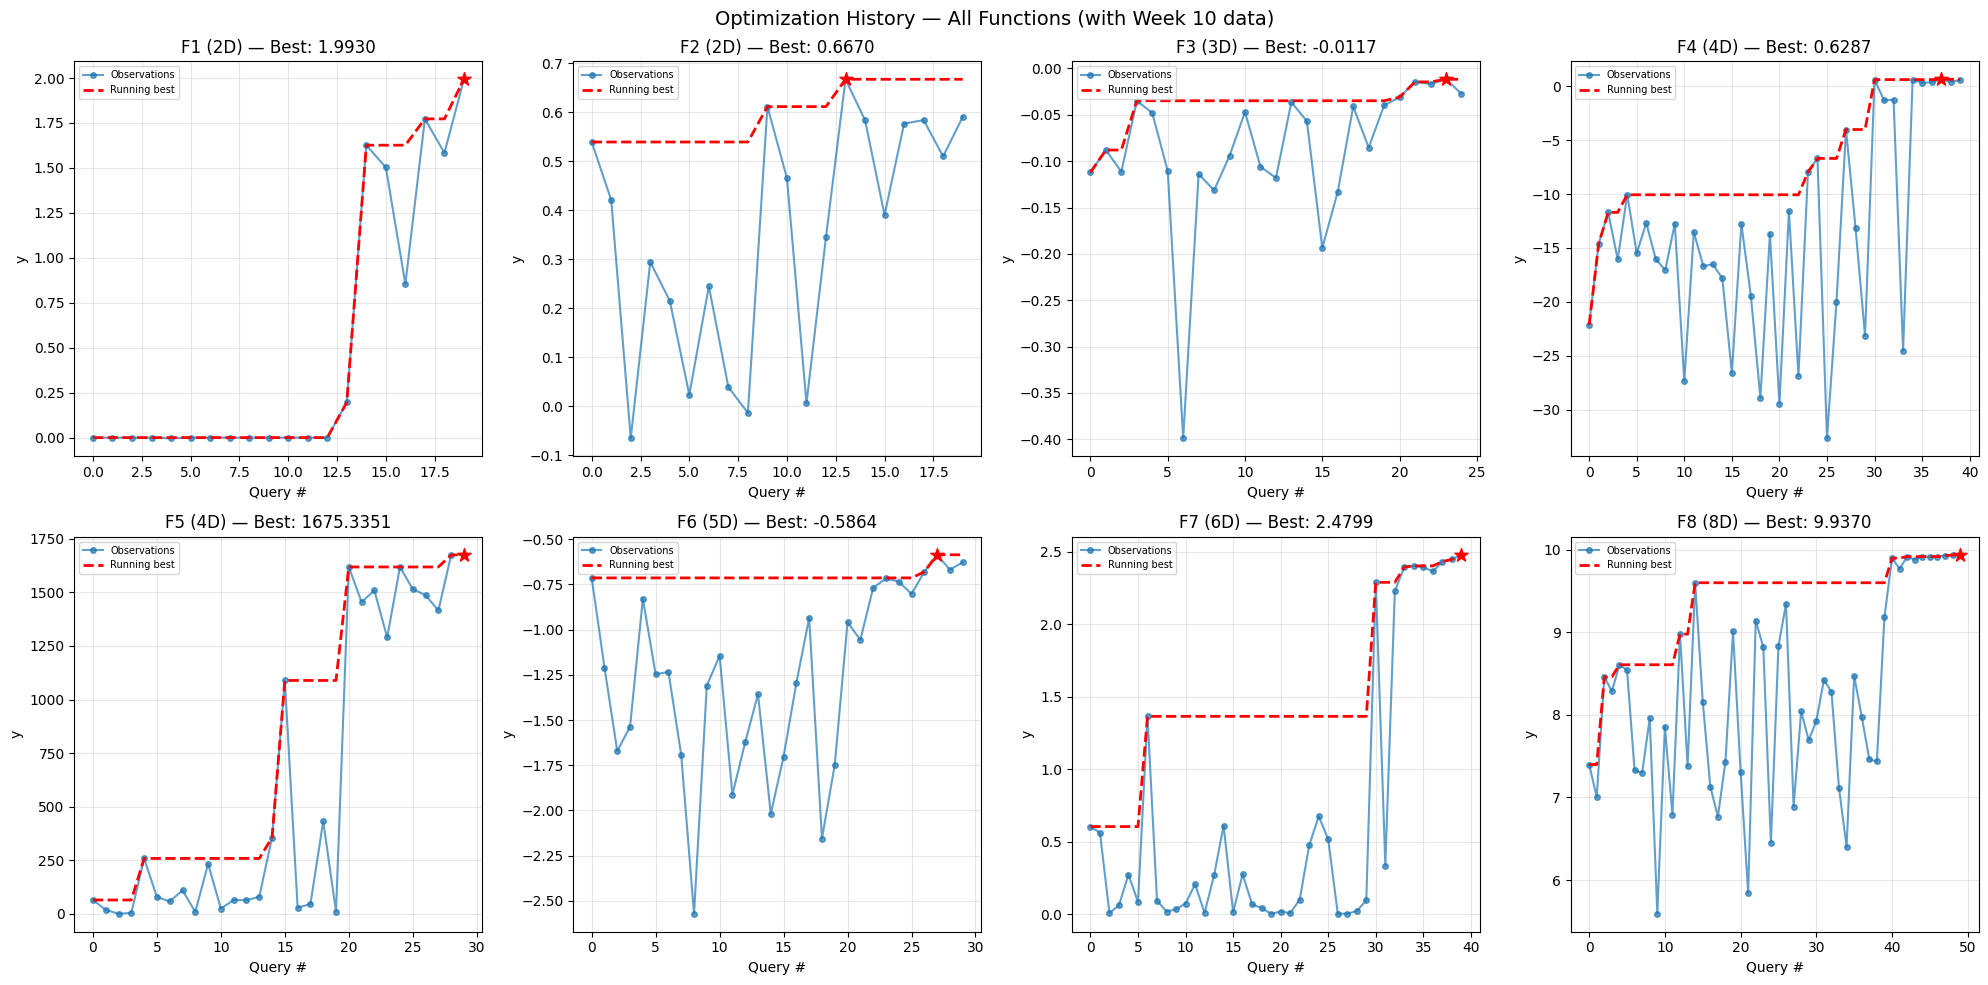

Saved optimization history plot.


In [16]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Optimization History — All Functions (with Week 10 data)', fontsize=14)

for idx, func_id in enumerate(range(1, 9)):
    ax = axes[idx // 4, idx % 4]
    df = all_data[func_id]
    
    y_vals = df['y'].values
    ax.plot(range(len(y_vals)), y_vals, 'o-', markersize=4, alpha=0.7, label='Observations')
    
    running_best = np.maximum.accumulate(y_vals)
    ax.plot(range(len(y_vals)), running_best, 'r--', linewidth=2, label='Running best')
    
    best_idx_plot = np.argmax(y_vals)
    ax.scatter(best_idx_plot, y_vals[best_idx_plot], c='red', s=100, zorder=5, marker='*')
    
    ax.set_title(f'F{func_id} ({dims[func_id]}D) — Best: {best_values[func_id]:.4f}')
    ax.set_xlabel('Query #')
    ax.set_ylabel('y')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()

import os
docs_dir = os.path.join(os.path.dirname(os.path.abspath('.')), 'docs')
os.makedirs(docs_dir, exist_ok=True)
plt.savefig(os.path.join(docs_dir, 'week11_optimization_history.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved optimization history plot.")

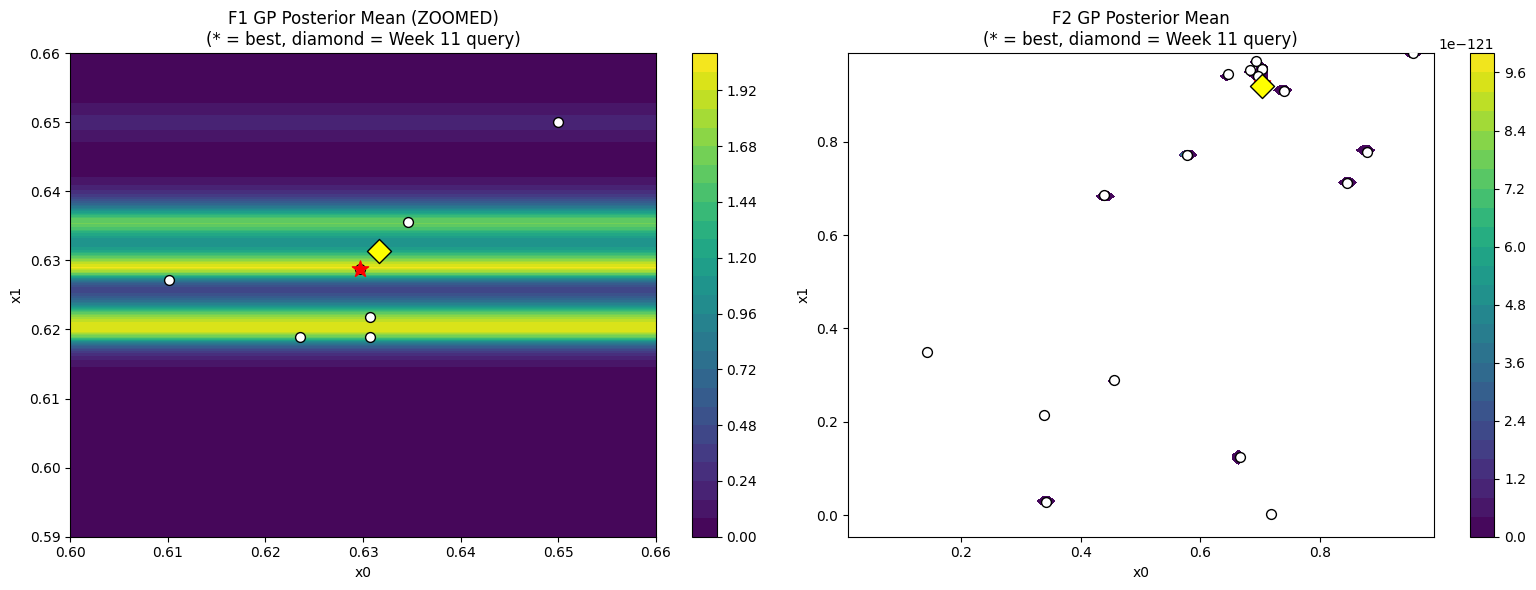

In [17]:
# GP landscape visualization for 2D functions (F1, F2)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for plot_idx, func_id in enumerate([1, 2]):
    ax = axes[plot_idx]
    df = all_data[func_id]
    X = df[['x0', 'x1']].values
    y = df['y'].values
    
    kernel = ConstantKernel(1.0) * Matern(length_scale=[1.0, 1.0], nu=1.5)
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-6)
    gp.fit(X, y)
    
    # Zoomed grid for F1 (around the peak)
    if func_id == 1:
        x0_grid = np.linspace(0.60, 0.66, 100)
        x1_grid = np.linspace(0.59, 0.66, 100)
    else:
        x0_grid = np.linspace(0.01, 0.99, 100)
        x1_grid = np.linspace(0.01, 0.99, 100)
    
    X0, X1 = np.meshgrid(x0_grid, x1_grid)
    X_grid = np.column_stack([X0.ravel(), X1.ravel()])
    mu_grid = gp.predict(X_grid).reshape(100, 100)
    
    im = ax.contourf(X0, X1, mu_grid, levels=30, cmap='viridis')
    plt.colorbar(im, ax=ax)
    
    # Data points
    if func_id == 1:
        mask = (X[:, 0] > 0.60) & (X[:, 0] < 0.66) & (X[:, 1] > 0.59) & (X[:, 1] < 0.66)
        ax.scatter(X[mask, 0], X[mask, 1], c='white', edgecolors='black', s=50, zorder=5)
    else:
        ax.scatter(X[:, 0], X[:, 1], c='white', edgecolors='black', s=50, zorder=5)
    
    best_idx_plot = np.argmax(y)
    ax.scatter(X[best_idx_plot, 0], X[best_idx_plot, 1], c='red', s=150, marker='*', zorder=6)
    
    q = week11_queries[func_id]
    ax.scatter(q[0], q[1], c='yellow', s=150, marker='D', zorder=6, edgecolors='black')
    
    title = f'F{func_id} GP Posterior Mean'
    if func_id == 1:
        title += ' (ZOOMED)'
    ax.set_title(f'{title}\n(* = best, diamond = Week 11 query)')
    ax.set_xlabel('x0')
    ax.set_ylabel('x1')

plt.tight_layout()
plt.savefig(os.path.join(docs_dir, 'week11_gp_landscape.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary and Submission

In [18]:
print("\n" + "=" * 70)
print("WEEK 11 (MODULE 22) — FINAL QUERIES")
print("HEBO-Inspired: Output Warping + Noisy EI + Multi-Acquisition")
print("=" * 70)

for func_id in range(1, 9):
    x = week11_queries[func_id]
    dim = dims[func_id]
    query_str = '-'.join([f"{v:.6f}" for v in x])
    best = best_values[func_id]
    print(f"\nFunction {func_id} ({dim}D):")
    print(f"  Query: {query_str}")
    print(f"  Best known: {best:.6f}")
    
    # Verify bounds
    assert np.all(x >= 0) and np.all(x <= 1), f"F{func_id} query out of bounds!"
    assert len(x) == dim, f"F{func_id} wrong dimension!"

print("\n" + "=" * 70)
print("All queries verified: within [0,1]^d, correct dimensions")
print("=" * 70)


WEEK 11 (MODULE 22) — FINAL QUERIES
HEBO-Inspired: Output Warping + Noisy EI + Multi-Acquisition

Function 1 (2D):
  Query: 0.631680-0.631385
  Best known: 1.993006

Function 2 (2D):
  Query: 0.702597-0.918887
  Best known: 0.666983

Function 3 (3D):
  Query: 0.532693-0.643951-0.387921
  Best known: -0.011662

Function 4 (4D):
  Query: 0.420406-0.380892-0.410213-0.421927
  Best known: 0.628683

Function 5 (4D):
  Query: 0.372961-0.280952-0.999999-0.999999
  Best known: 1675.335081

Function 6 (5D):
  Query: 0.689972-0.125676-0.758776-0.737728-0.050695
  Best known: -0.586391

Function 7 (6D):
  Query: 0.004063-0.141375-0.574198-0.242683-0.363648-0.735645
  Best known: 2.479887

Function 8 (8D):
  Query: 0.034514-0.081578-0.142709-0.061672-0.873622-0.356217-0.160895-0.237298
  Best known: 9.937023

All queries verified: within [0,1]^d, correct dimensions


In [19]:
# Save all submissions
for func_id in range(1, 9):
    x = week11_queries[func_id]
    query_str = '-'.join([f"{v:.6f}" for v in x])
    save_submission(func_id, query_str, module_name="Module 22")
    print(f"F{func_id}: Saved '{query_str}'")

Saved submission for Function 1 to submissions/submission_log.csv
F1: Saved '0.631680-0.631385'
Saved submission for Function 2 to submissions/submission_log.csv
F2: Saved '0.702597-0.918887'
Saved submission for Function 3 to submissions/submission_log.csv
F3: Saved '0.532693-0.643951-0.387921'
Saved submission for Function 4 to submissions/submission_log.csv
F4: Saved '0.420406-0.380892-0.410213-0.421927'
Saved submission for Function 5 to submissions/submission_log.csv
F5: Saved '0.372961-0.280952-0.999999-0.999999'
Saved submission for Function 6 to submissions/submission_log.csv
F6: Saved '0.689972-0.125676-0.758776-0.737728-0.050695'
Saved submission for Function 7 to submissions/submission_log.csv
F7: Saved '0.004063-0.141375-0.574198-0.242683-0.363648-0.735645'
Saved submission for Function 8 to submissions/submission_log.csv
F8: Saved '0.034514-0.081578-0.142709-0.061672-0.873622-0.356217-0.160895-0.237298'


## 9. Reflection: What Week 10 Taught Us

### Key Insights

1. **Coordinate-wise search unlocked F1**: Moving x1 from 0.622→0.629 gave +12.4%. The peak location was wrong by 0.007 in x1 — found by the GP's PI selection within a 0.005 trust region.

2. **F2 is definitively noisy**: Three evaluations of the exact same point [0.7026, 0.9266] gave 0.611, 0.667, 0.590. The Noisy EI upgrade (using GP-predicted best instead of observed best) is directly motivated by this.

3. **Trajectory overshooting is consistent**: F3 regressed at both +0.019/dim (W8) and +0.015/dim (W10). The optimum is very close to W9's position.

4. **F4 is even more peaked than thought**: Even r=0.010 from W8 best caused 15% regression. Ultra-tight r=0.003 is necessary.

5. **Output warping should help**: F1's y values span 1e-79 to 1.99, F5's span 0.1 to 1675. Yeo-Johnson transform will normalize these distributions for better GP fitting.

### HEBO Upgrades Rationale

The 3 upgrades come directly from HEBO (Huawei Noah's Ark Lab), winner of the NeurIPS 2020 BBO Challenge. Their ablation study showed:
- **Output warping** and **multi-objective acquisition** were the two most impactful components
- These are the highest-impact, lowest-effort improvements applicable to our sklearn GP framework

## Part 2: Reflect on Your Strategy

Now that we have submitted our 11th query and worked on our 11th iteration, we reflect more critically on our approach.

### 1. How have patterns in your past queries influenced your latest choices?

Past query patterns have been the **primary driver** of every Week 11 decision. Specific examples:

- **F1**: Weeks 1–7 explored broadly (x0 from 0.37 to 0.79, x1 from 0.02 to 0.98), producing values from near-zero to 0.85. Week 8 discovered the peak region near [0.631, 0.622] with y=1.773, but Week 9's tiny x1 shift (0.622→0.619) caused 10.7% regression, revealing an extremely narrow peak. Week 10's coordinate-wise adjustment (x1: 0.622→0.629) yielded the project's largest single-week gain (+12.4%). This pattern of "small shifts, dramatic consequences" directly motivated our ultra-tight r=0.003 radius for Week 11. The history shows F1's peak width is roughly 0.01 units — any larger exploration would almost certainly regress.

- **F2**: Seven consecutive submissions near [0.703, 0.927] produced values of 0.611, 0.667, 0.510, 0.590 — the same region yielding wildly different outputs. This pattern of **non-monotonic returns at identical locations** is the textbook signature of observation noise, which directly motivated our adoption of Noisy EI (using the GP-smoothed incumbent rather than the noisy observed best).

- **F7**: Three consecutive improvements (W8: 2.433 → W9: 2.448 → W10: 2.480) with a consistent x3-increasing direction (+0.011, then +0.016) provided the clearest directional signal in our dataset. We averaged the W8→W9 and W9→W10 displacement vectors to compute a robust direction estimate, then biased 40% of candidates along this direction.

- **F4/F6**: Both showed a pattern of "one good week followed by regressions when we tried to improve." F4's best (W8: 0.629) was followed by W9 (0.398, r=0.03) and W10 (0.536, r=0.010) — a clear signal that the function is extremely peaked and even moderate perturbations destroy performance. F6's trajectory hypothesis (W7→W8 showed clear directional improvement) was falsified by two consecutive failures (W9 full step, W10 half step). These failure patterns directly informed our decision to use ultra-tight radii (0.003 for F4, 0.005 for F6) and abandon the trajectory approach for F6.

### 2. Have you identified any 'clusters' or recurring regions in your search space that seem promising?

Yes, we have identified clear promising clusters for most functions, and the evidence strengthens with each week:

**Strong clusters (high confidence):**
- **F1**: A single sharp peak near [0.630, 0.629]. Our 8 queries in the region x0∈[0.62, 0.64], x1∈[0.59, 0.64] form a tight cluster with the 3 highest-value observations (1.993, 1.773, 1.583) all within 0.01 of each other. Outside this cluster, values drop precipitously (the initial random samples in other regions gave values below 0.3). This is consistent with a highly localized unimodal peak.

- **F5**: The cluster is defined by a **boundary structure**: x2 and x3 must be at or near 1.0 (the upper boundary), while x0∈[0.36, 0.38] and x1∈[0.27, 0.29] form the free-dimension cluster. Moving x2/x3 from 0.99→0.9999 produced +55 points; further to 1.0 gave another +1.1. The cluster is essentially a 2D ridge along the x2=x3=1 boundary face.

- **F8**: Queries cluster in a specific region of 8D space: x0∈[0.02, 0.04], x4∈[0.87, 0.91], with the remaining dimensions in moderate ranges. The 3 consecutive improvements (W8→W9→W10) all lie within a small neighbourhood, suggesting a relatively smooth, broad optimum in high-dimensional space.

**Moderate clusters (emerging):**
- **F3**: The best values cluster near [0.530, 0.639, 0.390]. W7, W8, W9, and W10 all queried within 0.02 of each other, but W9 (the best) sits precisely between W7 (slightly behind) and W8/W10 (slightly ahead, both worse). This suggests the peak is very close to the W9 position — the GP now has 4 bracketing points to triangulate it.

- **F7**: A trajectory cluster emerges in 6D space, with the recent improvements tracing a path primarily along the x3 axis (from 0.206→0.217→0.233). The cluster is elongated rather than spherical — more like a ridge in the x3 direction.

**Weak/no cluster:**
- **F2**: Despite 7 queries near [0.703, 0.927], the noisy responses (0.51–0.67) make it impossible to identify a reliable cluster. The region x1<0.920 near x0≈0.703 is a genuine blind spot — no queries have probed there — which is why Week 11 specifically forces exploration into this untested region.

- **F4**: Two positive evaluations (0.600 at W1, 0.629 at W8) are close in 4D space, suggesting a cluster near [0.42, 0.39, 0.41, 0.42], but the function is so peaked that even r=0.010 perturbations destroy performance. The "cluster" is essentially a single point with a very tight basin of attraction.

### 3. Which strategies or parameter choices have proven less effective, and how are you adjusting for them?

Several strategies have been clearly ineffective, and we have adjusted accordingly:

| Failed Strategy | Evidence | Week 11 Adjustment |
|----------------|----------|---------------------|
| **EI with large radius** | F4 W9: EI selected a point r=0.03 from best, causing -37% regression. EI rewards uncertainty, so it naturally selects points *further* from the known best. | Replaced EI as primary selector with multi-acquisition ensemble. PI weight (0.5–0.6) dominates for peaked functions. |
| **Thompson Sampling override** | F1 W9: TS selected x1=0.592 (0.030 from peak) during supposed "exploitation," causing -10.7%. The threshold `0.01 * \|y_best\|` is scale-dependent. | Removed TS override entirely. Never used since W9. |
| **Trajectory extrapolation** | F6 W9: Full step along W7→W8 direction regressed. W10: Half step also regressed. Two failures = hypothesis falsified. | Abandoned trajectory for F6. Now using GP-guided perpendicular search (r=0.005) to find improvements in orthogonal directions. |
| **Fixed trust region radius** | Using r=0.025 on F1 (W7) caused certain regression. Using r=0.010 on F4 (W10) also regressed. One-size-fits-all radii ignore peak width variation. | Radii now calibrated per-function: r=0.003 (F1, F4), r=0.005 (F3, F6), r=0.006 (F8), r=0.010 (F7), r=0.015 (F2). |
| **Domain clipping [0.01, 0.99]** | Destroyed 7/8 F5 submissions by preventing x2/x3 from reaching their optimal boundary values near 1.0. | Fixed to [0, 1] clipping in W9. F5 gained +55.7 points immediately. Pinning now applied AFTER clipping. |
| **Single acquisition function** | Different acquisition functions recommend different points. Betting on one (e.g., pure PI) can miss points that balance exploitation and mild exploration. | Adopted HEBO-style multi-acquisition ensemble: normalized PI (0.5) + EI (0.3) + UCB (0.2) combined score. |
| **StandardScaler on y** | F1's y values span from ~1e-79 to 1.99; F5's span 0.1 to 1675. StandardScaler assumes symmetric distribution, which fails on heavily skewed data. | Replaced with Yeo-Johnson PowerTransformer (HEBO's top technique), which automatically handles skewed distributions and maps them closer to Gaussian. |

### 4. In what ways do your refinements parallel how clustering algorithms separate meaningful patterns from noise?

Our Bayesian Optimization refinements share deep structural parallels with clustering algorithms:

**Density-based clustering (DBSCAN analogy):** Just as DBSCAN identifies core points in high-density regions and treats sparse points as noise, our trust region approach concentrates candidates around "core" high-value observations. The trust region radius functions like DBSCAN's epsilon parameter — it defines the neighbourhood size. Our key learning that **radius must match peak width** mirrors DBSCAN's sensitivity to epsilon: too large and distinct clusters merge (analogous to our trust region covering both peak and valley, causing regression); too small and meaningful structure is missed (analogous to under-exploration).

**Noise handling (F2):** F2's behaviour — same input yielding values of 0.611, 0.667, and 0.590 — is precisely the kind of observation noise that clustering algorithms must handle. Our Noisy EI upgrade parallels how robust clustering methods (e.g., HDBSCAN) use density smoothing rather than raw point positions: instead of treating the observed maximum as the "cluster center," we use the GP's smoothed posterior mean, which filters out observation noise just as kernel density estimation smooths noisy point distributions.

**Hierarchical refinement (agglomerative clustering analogy):** Our multi-week strategy mirrors hierarchical clustering's coarse-to-fine approach. Early weeks used broad exploration (r=0.15, like initial large-distance cluster merging), middle weeks used moderate trust regions (r=0.03–0.05, like intermediate merging), and late weeks use ultra-tight exploitation (r=0.003–0.006, like final fine-grained separation). Each stage's "cluster assignments" (promising regions) inform the next stage's search, just as each level of a dendrogram informs the next.

**Feature importance (dimensionality reduction analogy):** For F5, we identified that x2 and x3 are effectively "solved" (pinned at 1.0), reducing the effective search from 4D to 2D — analogous to PCA or feature selection identifying which dimensions carry meaningful variance. For F7, the directional analysis revealed that x3 carries the most consistent improvement signal, paralleling how clustering in a projected subspace (the x3 axis) reveals structure invisible in the full 6D space.

**Mixture model decomposition:** Our multi-kernel GP ensemble (Matern ν=0.5, 1.5, 2.5 with learned weights) parallels Gaussian Mixture Models: we don't assume a single smoothness level but instead let the data determine the mixture. Functions F1–F6 weight ν=0.5 heavily (rough, peaked surfaces), while F7–F8 prefer ν=2.5 (smooth surfaces) — the ensemble automatically "clusters" functions by their roughness characteristics.

### 5. If your query results were plotted, what trends or groupings might appear? How could these inform your next iteration?

If we plotted all queries for each function, several distinct visual patterns would emerge:

**F1 (2D scatter plot):** A dramatic "funnel" pattern — early queries scattered across [0, 1]² with low values (coloured blue/cold), converging to a tight cluster near [0.630, 0.629] with the highest values (coloured red/hot). The zoomed GP landscape (already plotted in Section 7) shows this clearly: a single sharp peak surrounded by near-zero values. The key insight for Week 12 is that the cluster is now so tight (all recent queries within 0.003 of each other) that further improvement is unlikely — this function should transition to EXACT_RETURN.

**F5 (boundary ridge):** Plotting x2 vs y would show a sharp exponential-like increase as x2 → 1.0, confirming the boundary optimum. Plotting x0 vs x1 (with x2/x3 fixed near 1.0) would show a smooth 2D surface with a gentle maximum near (0.369, 0.277). The trend suggests diminishing returns — W9→W10 gained only +1.1 compared to W8→W9's +55.7. Week 12 should focus on sub-0.001 fine-tuning of x0/x1.

**F7 (trajectory plot):** Plotting the 6D queries projected onto the x3 axis over time would show a clear upward trend: 0.206 → 0.217 → 0.233 → 0.243 (Week 11 query). This ascending trajectory, correlated with monotonically improving y values (2.433 → 2.448 → 2.480), is the strongest directional signal in our dataset. If Week 11 continues the improvement, Week 12 should continue this direction with even smaller steps (approaching the peak from below). If Week 11 regresses, it signals we've overshot and the peak is between W10 and W11's x3 values.

**F4 (isolation plot):** In 4D, the positive-value observations (W1: 0.600, W8: 0.629) would appear as two isolated points in a sea of negative values. The surrounding queries (W9: 0.398, W10: 0.536, W11: ~0.42) form a small cluster around the W8 peak but with sharp drop-offs in every direction. This pattern — a single isolated peak with no surrounding positive-value structure — suggests the function has an extremely narrow basin of attraction. Week 12 should either use r ≤ 0.002 or simply EXACT_RETURN to W8's coordinates.

**F2 (noise cloud):** Plotting all queries near [0.703, 0.927] would show a "cloud" of overlapping points with widely varying y-values (0.51–0.67), with no spatial correlation between position and value. This is the visual signature of observation noise dominating the signal. The Week 11 query probes x1=0.919 (below the cloud), which would appear as an outlier extending the cluster downward — if it produces a high value, it reveals that the noisy cloud was obscuring a ridge extending toward lower x1.

**Cross-function groupings:** Plotting all 8 functions' "best value improvement over time" would reveal three groups: (1) **Converging** — F1, F5, F8 show monotonically increasing running bests that are flattening (diminishing returns); (2) **Oscillating** — F3, F4, F6 show a pattern of one good week followed by regressions, suggesting they've found the approximate peak but can't refine further; (3) **Trending** — F7 shows consistent improvement with no sign of plateauing, suggesting the optimum hasn't been reached yet. For Week 12 (the final exploration week), group 1 should use EXACT_RETURN or ultra-tight refinement, group 2 should use EXACT_RETURN to lock in their bests, and group 3 (F7) should continue directional exploitation.